In [ ]:
Stock Price Prediction using Time Series Analysis

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [16]:
df = pd.read_csv("yahoo_stock.csv")
df

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107
...,...,...,...,...,...,...,...
1820,2020-11-16,3628.510010,3600.159912,3600.159912,3626.909912,5.281980e+09,3626.909912
1821,2020-11-17,3623.110107,3588.679932,3610.310059,3609.530029,4.799570e+09,3609.530029
1822,2020-11-18,3619.090088,3567.330078,3612.090088,3567.790039,5.274450e+09,3567.790039
1823,2020-11-19,3585.219971,3543.840088,3559.409912,3581.870117,4.347200e+09,3581.870117


In [17]:
df = pd.read_csv("yahoo_stock.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

data = df['Close']

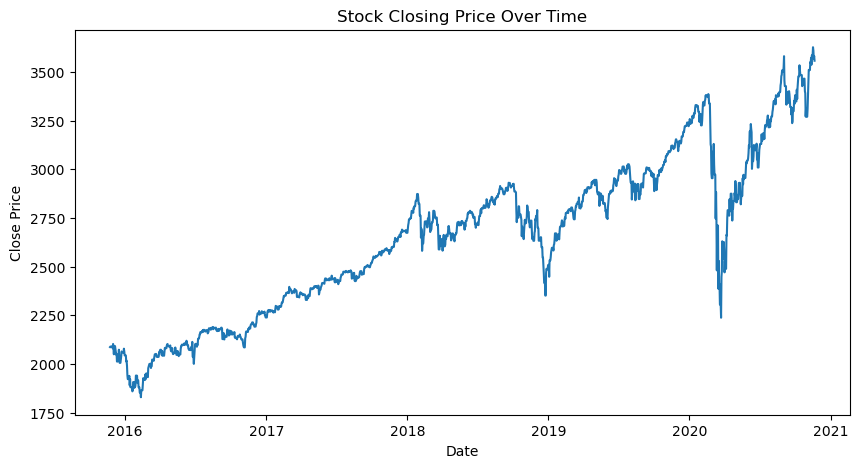

In [18]:
plt.figure(figsize=(10,5))
plt.plot(data)
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

In [19]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.8703973870161086
p-value: 0.7975646340657581


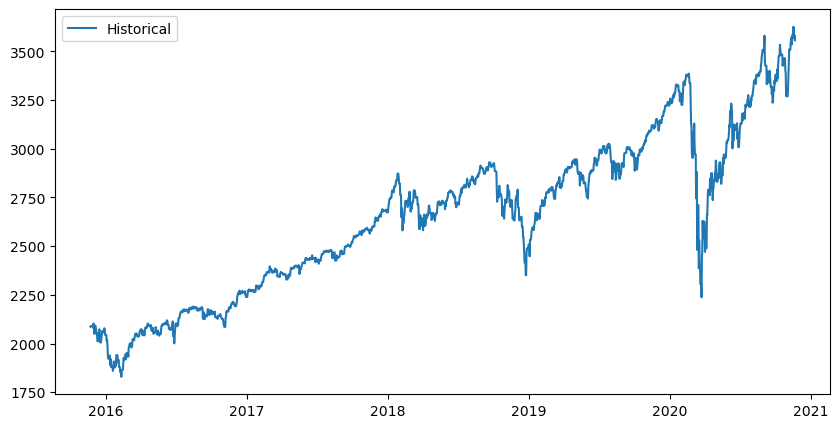

In [21]:
plt.figure(figsize=(10,5))
plt.plot(data, label='Historical')
plt.legend()
plt.show()

In [22]:
train = data[:int(len(data)*0.8)]
test = data[int(len(data)*0.8):]

model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

predictions = model_fit.forecast(steps=len(test))

mse = mean_squared_error(test, predictions)
print("Mean Squared Error:", mse)

C:\Users\acer\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\acer\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\acer\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Mean Squared Error: 77620.68519390817
